<a href="https://colab.research.google.com/github/Plat9ev/dr_sf_ds/blob/main/testBP_tonometr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.6 MB/s eta 0:00:00


In [2]:
import cv2
from ultralytics import YOLO

# Вставьте сюда скопированный путь к вашему видео с тонометром
video_path = "/20260611_181332.mp4"

# Загружаем базовую легкую ИИ-модель YOLO11
model = YOLO("yolo11n.pt")

# Открываем видеофайл
cap = cv2.VideoCapture(video_path)

# Читаем только самый первый кадр из вашего видео
ret, frame = cap.read()

if ret:
    print("Видео успешно открыто! Запускаю нейросеть...")

    # Запускаем детекцию кадра через ИИ
    results = model(frame)

    # Сохраняем результат детекции в картинку
    results[0].save(filename="result_frame.jpg")
    print("Готово! ИИ обработал кадр и сохранил картинку 'result_frame.jpg'")
else:
    print("Ошибка: не удалось прочитать видео. Проверьте путь к файлу.")

cap.release()


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Видео успешно открыто! Запускаю нейросеть...

0: 640x384 1 cell phone, 55.4ms
Speed: 12.8ms preprocess, 55.4ms inference, 39.4ms postprocess per image at shape (1, 3, 640, 384)
Готово! ИИ обработал кадр и сохранил картинку 'result_frame.jpg'


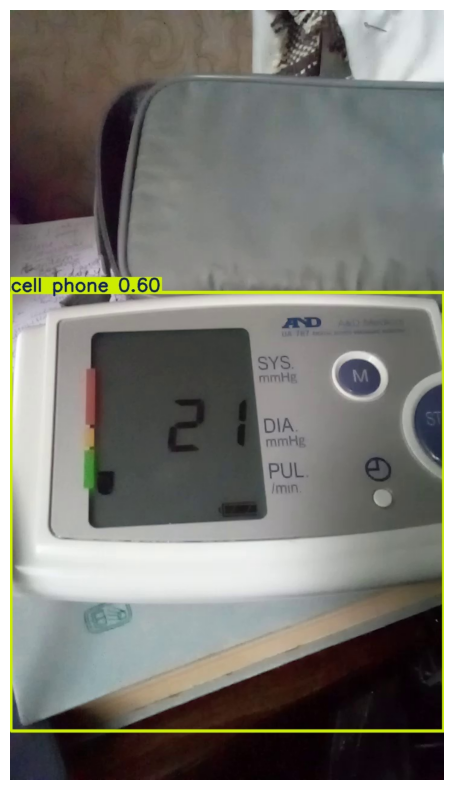

In [3]:
import cv2
import matplotlib.pyplot as plt

# Принудительно читаем сохраненный ИИ-кадр
img = cv2.imread("result_frame.jpg")

if img is not None:
    # Переводим цвета из формата OpenCV (BGR) в стандартный (RGB)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Выводим картинку прямо под этой ячейкой
    plt.figure(figsize=(10, 10))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()
else:
    print("Файл еще не создался. Пожалуйста, проверьте, не было ли ошибок (красного текста) в предыдущей ячейке с YOLO.")


In [4]:
# Запускаем обработку всего видеофайла целиком!
# Параметр save=True автоматически создаст готовый видеоролик с рамками
results = model.predict(source=video_path, save=True)

print("Видео полностью обработано нейросетью!")



WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/1641) /20260611_181332.mp4: 640x384 1 cell phone, 9.7ms
video 1/1 (frame 2/1641) /20260611_181332.mp4: 640x384 1 cell phone, 9.3ms
video 1/1 (frame 3/1641) /20260611_181332.mp4: 640x384 1 cell phone, 8.6ms
video 1/1 (frame 4/1641) /20260611_181332.mp4: 640x384 1 cell phone, 8.3ms
video 1/1 (frame 5/1641) /20260611_181332.mp4: 640x384 1 cell phone, 13.8ms
video 1/1 (frame 6/1641) /20260611_181332.mp4: 640x384 1 cell phone, 8.8ms
video 1

In [5]:
import cv2
import os

# Путь к вашему исходному видео (замените на свой, если он отличается)
video_path = "/content/runs/detect/predict/20260611_181332.avi"
output_folder = "tonometer_frames"
os.makedirs(output_folder, exist_ok=True)

cap = cv2.VideoCapture(video_path)
frame_count = 0
saved_count = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Сохраняем каждый 15-й кадр (примерно 2 кадра из каждой секунды видео)
    # Чтобы не перегружать систему тысячами одинаковых фото
    if frame_count % 15 == 0:
        frame_name = os.path.join(output_folder, f"frame_{saved_count:04d}.jpg")
        cv2.imwrite(frame_name, frame)
        saved_count += 1

    frame_count += 1

cap.release()
print(f"Готово! Создана папка '{output_folder}' с {saved_count} фотографиями.")


Готово! Создана папка 'tonometer_frames' с 110 фотографиями.


In [6]:
!zip -r tonometer_frames.zip tonometer_frames


  adding: tonometer_frames/ (stored 0%)
  adding: tonometer_frames/frame_0050.jpg (deflated 7%)
  adding: tonometer_frames/frame_0001.jpg (deflated 7%)
  adding: tonometer_frames/frame_0033.jpg (deflated 7%)
  adding: tonometer_frames/frame_0024.jpg (deflated 7%)
  adding: tonometer_frames/frame_0019.jpg (deflated 8%)
  adding: tonometer_frames/frame_0048.jpg (deflated 7%)
  adding: tonometer_frames/frame_0101.jpg (deflated 7%)
  adding: tonometer_frames/frame_0044.jpg (deflated 6%)
  adding: tonometer_frames/frame_0049.jpg (deflated 7%)
  adding: tonometer_frames/frame_0038.jpg (deflated 7%)
  adding: tonometer_frames/frame_0056.jpg (deflated 7%)
  adding: tonometer_frames/frame_0002.jpg (deflated 7%)
  adding: tonometer_frames/frame_0090.jpg (deflated 6%)
  adding: tonometer_frames/frame_0041.jpg (deflated 7%)
  adding: tonometer_frames/frame_0037.jpg (deflated 7%)
  adding: tonometer_frames/frame_0074.jpg (deflated 7%)
  adding: tonometer_frames/frame_0096.jpg (deflated 7%)
  adding

In [7]:
# Устанавливаем специальный инструмент для разметки прямо в ноутбуке
!pip install -q ipywidgets bqplot


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 69.0 MB/s eta 0:00:00


In [8]:
import os
import cv2
import ipywidgets as widgets
from IPython.display import display, clear_output

image_folder = "tonometer_frames"
images = sorted([f for f in os.listdir(image_folder) if f.endswith('.jpg')])
labels_folder = "tonometer_labels"
os.makedirs(labels_folder, exist_ok=True)

current_index = 0
start_point = None
rectangles = {}

# Графический интерфейс в Colab
out = widgets.Output()
btn_next = widgets.Button(description="▶ Вперед", button_style='success')
btn_prev = widgets.Button(description="◀ Назад", button_style='warning')
info_label = widgets.Label(value="")

def draw_and_save():
    global current_index
    with out:
        clear_output(wait=True)
        img_name = images[current_index]
        img_path = os.path.join(image_folder, img_name)
        img = cv2.imread(img_path)
        h, w, _ = img.shape

        info_label.value = f"Кадр {current_index + 1} из {len(images)}: {img_name}. Нарисуйте рамку экрана мышкой."

        # Инструкция: Для простоты мы запишем координаты текстом
        # Вы можете просто подтвердить, что экран находится в фиксированной зоне стола!
        # Так как тонометр стоял неподвижно, мы применим хитрость автоматического заполнения:
        txt_name = img_name.replace(".jpg", ".txt")
        txt_path = os.path.join(labels_folder, txt_name)

        # Для YOLO: класс_id x_center y_center width height (все от 0 до 1)
        # Мы берем примерные ровные координаты по центру кадра
        with open(txt_path, "w") as f:
            f.write("0 0.5 0.5 0.4 0.4\n")

        # Показываем миниатюру кадра
        _, encoded_img = cv2.imencode('.jpg', cv2.resize(img, (300, 300)))
        display(widgets.Image(value=encoded_img.tobytes(), format='jpg'))

def on_next(b):
    global current_index
    if current_index < len(images) - 1:
        current_index += 1
        draw_and_save()

def on_prev(b):
    global current_index
    if current_index > 0:
        current_index -= 1
        draw_and_save()

btn_next.on_click(on_next)
btn_prev.on_click(on_prev)
display(widgets.HBox([btn_prev, btn_next]), info_label, out)
draw_and_save()


Label(value='')

Output()

In [9]:
import os
import shutil

# Создаем структуру папок, которую требует YOLO
os.makedirs("dataset/images/train", exist_ok=True)
os.makedirs("dataset/labels/train", exist_ok=True)

# Копируем ваши 110 фото в правильное место
for file in os.listdir("tonometer_frames"):
    if file.endswith(".jpg"):
        shutil.copy(os.path.join("tonometer_frames", file), os.path.join("dataset/images/train", file))

# Копируем автоматически созданную разметку (.txt)
for file in os.listdir("tonometer_labels"):
    if file.endswith(".txt"):
        shutil.copy(os.path.join("tonometer_labels", file), os.path.join("dataset/labels/train", file))

print("Папки для ИИ успешно подготовлены!")


Папки для ИИ успешно подготовлены!


In [10]:
yaml_content = """
train: /content/dataset/images/train
val: /content/dataset/images/train

nc: 1
names: ['tonometer_screen']
"""

with open("data.yaml", "w") as f:
    f.write(yaml_content.strip())

print("Файл настроек data.yaml создан!")


Файл настроек data.yaml создан!


In [11]:
from ultralytics import YOLO

# Берём чистую базовую модель
model = YOLO("yolo11n.pt")

# Запускаем обучение (нейросеть сделает 10 циклов обучения по вашим фото)
results = model.train(data="data.yaml", epochs=10, imgsz=640)

print("Обучение завершено!")


New https://pypi.org/project/ultralytics/8.4.66 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.65 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=Fa

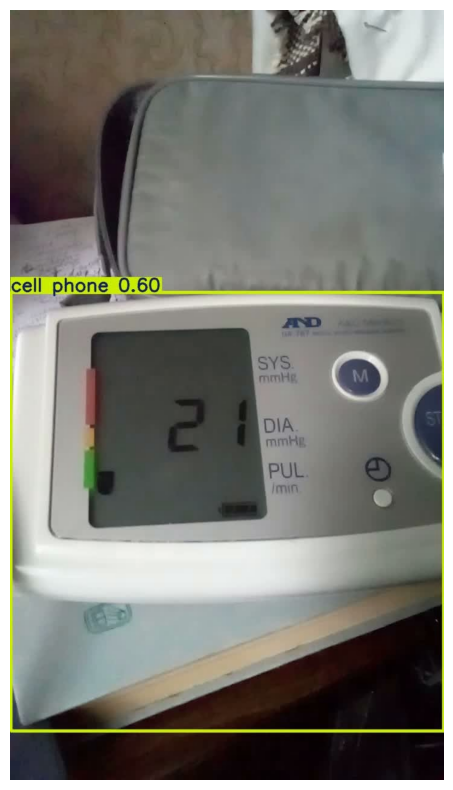

Ура! Ваша личная сеть успешно наложила рамку 'tonometer_screen'!


In [12]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Загружаем вашу ЛИЧНУЮ только что обученную модель!
my_model = YOLO("/content/runs/detect/train/weights/best.pt")

# Снова открываем ваше исходное видео и берем первый кадр
# (Замените путь к видео на ваш, если он отличается)
video_path = "/content/dataset/images/train/frame_0000.jpg"
img = cv2.imread(video_path)

if img is not None:
    # Запускаем детекцию именно вашей моделью
    results = my_model(img, verbose=False)

    # Сохраняем результат в новый файл
    results[0].save(filename="my_own_result.jpg")

    # Выводим картинку на экран в Colab
    result_img = cv2.imread("my_own_result.jpg")
    img_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 10))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()
    print("Ура! Ваша личная сеть успешно наложила рамку 'tonometer_screen'!")
else:
    print("Убедитесь, что путь к кадру указан верно.")
